# 04 — Twitch Neural Ranker (Mac-Safe)

Train a compact PyTorch MLP ranker on the same Twitch ranking features used in Notebook 03.

This version is designed for a laptop with limited RAM:

- training data is sampled **while reading the compressed CSV in chunks**
- test evaluation samples **users**, then keeps all candidate rows for those users
- preprocessing uses `float32`
- PyTorch uses a compact CPU model and `num_workers=0`
- the notebook records exactly how many rows/users were used

The goal is unchanged: compare a neural ranker with the classical ranking baselines and save a model that can later be benchmarked for inference.


In [1]:
import os
import gc
import json
import joblib
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------------------------------------------
# Locate project
# ------------------------------------------------------------------
PROJECT_CANDIDATES = [
    Path.cwd() / "Distributed ML Inference & Ranking",
    Path.cwd(),
    Path.home() / "Desktop" / "resume_projects" / "Distributed ML Inference & Ranking",
]

PROJECT_DIR = next(
    (
        p for p in PROJECT_CANDIDATES
        if (p / "data" / "processed" / "twitch").exists()
    ),
    None,
)

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Could not locate the project folder. "
        "Set PROJECT_DIR manually in this cell."
    )

DATA_DIR = PROJECT_DIR / "data/processed/twitch"
ARTIFACT_DIR = PROJECT_DIR / "artifacts/twitch"
PRED_DIR = DATA_DIR / "predictions"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "twitch_train_ranking.csv.gz"
TEST_PATH = DATA_DIR / "twitch_test_ranking.csv.gz"

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")

# Resource-aware limits. These are large enough for a useful experiment
# but small enough for a typical Mac laptop.
MAX_TRAIN_ROWS = 400_000
MAX_TEST_USERS = 5_000
CSV_CHUNK_SIZE = 75_000
BATCH_SIZE = 1024
EPOCHS = 3

# Avoid CPU thread oversubscription.
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))

print("Project:", PROJECT_DIR)
print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("Max train rows:", f"{MAX_TRAIN_ROWS:,}")
print("Max test users:", f"{MAX_TEST_USERS:,}")


Project: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/notebooks/Distributed ML Inference & Ranking
Device: cpu
Torch: 2.14.0
Max train rows: 400,000
Max test users: 5,000


## 1. Load data and define features

In [2]:
# Read only the header first.
header = pd.read_csv(TRAIN_PATH, nrows=0)

ID_COLUMNS = ["user_id", "streamer"]
LABEL_COLUMN = "label"
FUTURE_ONLY_COLUMNS = ["future_interactions", "future_watch_minutes"]

FEATURE_COLUMNS = [
    c for c in header.columns
    if c not in ID_COLUMNS + [LABEL_COLUMN] + FUTURE_ONLY_COLUMNS
]

USE_COLUMNS = ID_COLUMNS + [LABEL_COLUMN] + FEATURE_COLUMNS

print("Ranking features:", len(FEATURE_COLUMNS))
print("Columns loaded:", len(USE_COLUMNS))


def load_training_sample(
    path,
    usecols,
    max_rows=400_000,
    chunksize=75_000,
    seed=42,
):
    """Randomly sample rows chunk-by-chunk without loading the full CSV."""
    rng = np.random.default_rng(seed)
    sampled = []
    seen = 0

    # Use a moderate sampling fraction, then cap exactly at max_rows.
    # This avoids loading the full 1M+ row training table into RAM.
    sample_frac = 0.30

    for chunk_id, chunk in enumerate(
        pd.read_csv(path, usecols=usecols, chunksize=chunksize)
    ):
        seen += len(chunk)

        n = max(1, int(len(chunk) * sample_frac))
        n = min(n, len(chunk))

        piece = chunk.sample(
            n=n,
            random_state=seed + chunk_id,
        )

        sampled.append(piece)

        current = sum(len(x) for x in sampled)
        if current >= max_rows:
            break

        del chunk, piece
        gc.collect()

    out = pd.concat(sampled, ignore_index=True)

    if len(out) > max_rows:
        out = out.sample(
            n=max_rows,
            random_state=seed,
        ).reset_index(drop=True)

    print(f"Training rows scanned: {seen:,}")
    print(f"Training rows kept:    {len(out):,}")

    return out


def sample_test_user_ids(
    path,
    max_users=5_000,
    seed=42,
):
    """Read only user_id, choose users, then later load their full rows."""
    user_ids = pd.read_csv(
        path,
        usecols=["user_id"],
    )["user_id"].drop_duplicates()

    rng = np.random.default_rng(seed)

    if len(user_ids) > max_users:
        selected = rng.choice(
            user_ids.to_numpy(),
            size=max_users,
            replace=False,
        )
    else:
        selected = user_ids.to_numpy()

    print(f"Unique test users available: {len(user_ids):,}")
    print(f"Test users selected:         {len(selected):,}")

    return set(selected.tolist())


def load_test_users(
    path,
    selected_users,
    usecols,
    chunksize=75_000,
):
    """Load complete candidate groups for selected users only."""
    parts = []

    for chunk in pd.read_csv(
        path,
        usecols=usecols,
        chunksize=chunksize,
    ):
        keep = chunk["user_id"].isin(selected_users)

        if keep.any():
            parts.append(chunk.loc[keep].copy())

        del chunk
        gc.collect()

    if not parts:
        raise ValueError("No rows found for selected test users.")

    return pd.concat(parts, ignore_index=True)


train = load_training_sample(
    TRAIN_PATH,
    usecols=USE_COLUMNS,
    max_rows=MAX_TRAIN_ROWS,
    chunksize=CSV_CHUNK_SIZE,
    seed=SEED,
)

selected_test_users = sample_test_user_ids(
    TEST_PATH,
    max_users=MAX_TEST_USERS,
    seed=SEED,
)

test = load_test_users(
    TEST_PATH,
    selected_users=selected_test_users,
    usecols=USE_COLUMNS,
    chunksize=CSV_CHUNK_SIZE,
)

print("\nTrain sample:", train.shape)
print("Test subset: ", test.shape)
print("Test users:  ", test["user_id"].nunique())
print("Train positive rate:", round(train[LABEL_COLUMN].mean(), 6))
print("Test positive rate: ", round(test[LABEL_COLUMN].mean(), 6))


Ranking features: 36
Columns loaded: 39
Training rows scanned: 496,140
Training rows kept:    148,842
Unique test users available: 10,000
Test users selected:         5,000

Train sample: (148842, 39)
Test subset:  (118750, 39)
Test users:   5000
Train positive rate: 0.200447
Test positive rate:  0.2


## 2. Fit preprocessing on training data only

In [3]:
# Convert only the feature block to float32 before sklearn transforms.
# This substantially reduces memory versus the original float64 pipeline.
train_features = train[FEATURE_COLUMNS].astype(np.float32)
test_features = test[FEATURE_COLUMNS].astype(np.float32)

imputer = SimpleImputer(
    strategy="median",
    copy=False,
)

X_train = imputer.fit_transform(train_features)
X_test = imputer.transform(test_features)

# Release DataFrame feature copies before scaling.
del train_features, test_features
gc.collect()

scaler = StandardScaler(copy=False)

X_train = scaler.fit_transform(X_train).astype(
    np.float32,
    copy=False,
)
X_test = scaler.transform(X_test).astype(
    np.float32,
    copy=False,
)

y_train = train[LABEL_COLUMN].to_numpy(
    dtype=np.float32,
    copy=True,
)
y_test = test[LABEL_COLUMN].to_numpy(
    dtype=np.float32,
    copy=True,
)

print("X_train:", X_train.shape, X_train.dtype)
print("X_test: ", X_test.shape, X_test.dtype)
print(
    "Approx feature-array memory:",
    f"{(X_train.nbytes + X_test.nbytes) / 1024**2:.1f} MB"
)


X_train: (148842, 36) float32
X_test:  (118750, 36) float32
Approx feature-array memory: 36.7 MB


## 3. Create PyTorch data loaders

In [4]:
train_ds = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train),
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

print(f"Batch size: {BATCH_SIZE:,}")
print(f"Training batches: {len(train_loader):,}")


Batch size: 1,024
Training batches: 146


## 4. Define neural ranking model

In [5]:
class TwitchMLPRanker(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 48),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(48, 24),
            nn.ReLU(),

            nn.Linear(24, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


model = TwitchMLPRanker(
    input_dim=len(FEATURE_COLUMNS)
).to(DEVICE)

print(model)

parameter_count = sum(
    p.numel() for p in model.parameters()
)

print("Trainable parameters:", f"{parameter_count:,}")


TwitchMLPRanker(
  (network): Sequential(
    (0): Linear(in_features=36, out_features=48, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): ReLU()
    (5): Linear(in_features=24, out_features=1, bias=True)
  )
)
Trainable parameters: 2,977


## 5. Train

In [6]:
LEARNING_RATE = 1e-3

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

loss_fn = nn.BCEWithLogitsLoss()

history = []

for epoch in range(1, EPOCHS + 1):
    model.train()

    running_loss = 0.0
    n_examples = 0
    start = perf_counter()

    for features, labels in train_loader:
        # CPU-only: no extra device copies are needed.
        optimizer.zero_grad(set_to_none=True)

        logits = model(features)
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()

        batch_n = labels.shape[0]
        running_loss += loss.item() * batch_n
        n_examples += batch_n

    epoch_loss = running_loss / n_examples
    elapsed = perf_counter() - start

    history.append(
        {
            "epoch": epoch,
            "train_loss": epoch_loss,
            "seconds": elapsed,
        }
    )

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"loss={epoch_loss:.5f} | "
        f"time={elapsed:.2f}s"
    )


Epoch 1/3 | loss=0.32388 | time=0.57s
Epoch 2/3 | loss=0.23366 | time=0.45s
Epoch 3/3 | loss=0.23174 | time=0.45s


## 6. Plot training loss

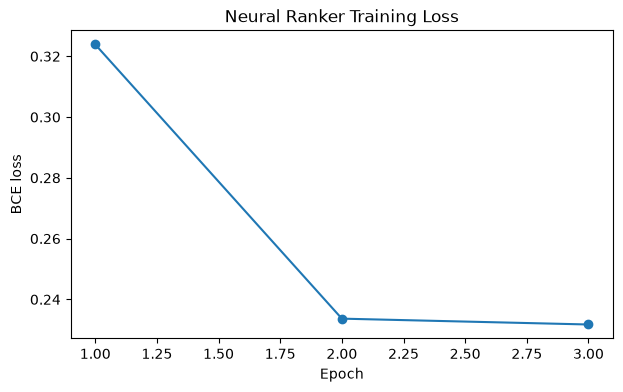

In [7]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(7, 4))
plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
)
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Neural Ranker Training Loss")
plt.show()

## 7. Run batched inference on test data

In [8]:
def predict_in_batches(
    model,
    X,
    batch_size=4096,
):
    model.eval()
    scores = []

    with torch.inference_mode():
        for start in range(0, len(X), batch_size):
            batch_np = X[start:start + batch_size]
            batch = torch.from_numpy(batch_np)

            logits = model(batch)
            probs = torch.sigmoid(logits)

            scores.append(
                probs.numpy()
            )

    return np.concatenate(scores)


start = perf_counter()

neural_scores = predict_in_batches(
    model,
    X_test,
    batch_size=4096,
)

elapsed = perf_counter() - start

print(f"Inference rows: {len(X_test):,}")
print(f"Inference time: {elapsed:.4f} seconds")
print(f"Throughput: {len(X_test) / elapsed:,.0f} rows/sec")


Inference rows: 118,750
Inference time: 0.0084 seconds
Throughput: 14,085,481 rows/sec


In [9]:
print(
    "ROC-AUC:",
    f"{roc_auc_score(y_test, neural_scores):.4f}",
)
print(
    "Average Precision:",
    f"{average_precision_score(y_test, neural_scores):.4f}",
)

ROC-AUC: 0.9205
Average Precision: 0.8642


## 8. Evaluate ranking quality

In [10]:
def ranking_metrics(frame, score_col, ks=(5, 10, 20)):
    ranked = frame.sort_values(
        ["user_id", score_col],
        ascending=[True, False],
    )

    results = []

    for user_id, group in ranked.groupby("user_id", sort=False):
        labels = group["label"].to_numpy()
        positives = labels.sum()

        if positives == 0:
            continue

        row = {"user_id": user_id}

        pos = np.flatnonzero(labels == 1)
        row["MRR"] = 1.0 / (pos[0] + 1)

        for k in ks:
            top = labels[:k]
            row[f"Recall@{k}"] = top.sum() / positives

            discounts = 1.0 / np.log2(
                np.arange(2, len(top) + 2)
            )
            dcg = (top * discounts).sum()

            ideal_len = min(int(positives), k)
            idcg = (
                1.0 / np.log2(
                    np.arange(2, ideal_len + 2)
                )
            ).sum()

            row[f"NDCG@{k}"] = dcg / idcg

        results.append(row)

    per_user = pd.DataFrame(results)
    return per_user.mean(numeric_only=True)


predictions = test[
    ["user_id", "streamer", "label", "seen_before"]
].copy()

predictions["score_neural"] = neural_scores

ranking_metrics(
    predictions,
    "score_neural",
)

user_id      50438.085000
MRR              0.959652
Recall@5         0.796366
NDCG@5           0.912669
Recall@10        0.909004
NDCG@10          0.915121
Recall@20        0.963720
NDCG@20          0.924068
dtype: float64

## 9. Save neural ranker artifacts

In [11]:
torch.save(
    {
        "state_dict": model.state_dict(),
        "input_dim": len(FEATURE_COLUMNS),
        "feature_columns": FEATURE_COLUMNS,
        "architecture": [48, 24],
    },
    ARTIFACT_DIR / "neural_ranker.pt",
)

joblib.dump(
    {
        "imputer": imputer,
        "scaler": scaler,
        "feature_columns": FEATURE_COLUMNS,
    },
    ARTIFACT_DIR / "neural_ranker_preprocessing.joblib",
)

predictions.to_csv(
    PRED_DIR / "neural_predictions_mac_subset.csv.gz",
    index=False,
    compression="gzip",
)

history_df.to_csv(
    ARTIFACT_DIR / "neural_training_history.csv",
    index=False,
)

pd.Series(
    sorted(selected_test_users),
    name="user_id",
).to_csv(
    ARTIFACT_DIR / "neural_eval_user_ids.csv",
    index=False,
)

run_metadata = {
    "seed": SEED,
    "train_rows": int(len(train)),
    "test_rows": int(len(test)),
    "test_users": int(test["user_id"].nunique()),
    "max_train_rows_config": MAX_TRAIN_ROWS,
    "max_test_users_config": MAX_TEST_USERS,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "feature_count": len(FEATURE_COLUMNS),
    "device": str(DEVICE),
}

with open(
    ARTIFACT_DIR / "neural_ranker_run_metadata.json",
    "w",
) as f:
    json.dump(run_metadata, f, indent=2)

print("Saved:")
print("- neural_ranker.pt")
print("- neural_ranker_preprocessing.joblib")
print("- neural_predictions_mac_subset.csv.gz")
print("- neural_training_history.csv")
print("- neural_eval_user_ids.csv")
print("- neural_ranker_run_metadata.json")


Saved:
- neural_ranker.pt
- neural_ranker_preprocessing.joblib
- neural_predictions_mac_subset.csv.gz
- neural_training_history.csv
- neural_eval_user_ids.csv
- neural_ranker_run_metadata.json


## 10. Save a TorchScript version for later inference benchmarks

This artifact is useful in Notebook 07, where we compare regular PyTorch inference with a traced model.


In [12]:
model.eval()

example_input = torch.zeros(
    1,
    len(FEATURE_COLUMNS),
    dtype=torch.float32,
)

traced_model = torch.jit.trace(
    model.cpu(),
    example_input,
)

traced_model.save(
    str(ARTIFACT_DIR / "neural_ranker_traced.pt")
)

print("Saved TorchScript model.")

Saved TorchScript model.


/opt/anaconda3/envs/distributed-ml/lib/python3.11/site-packages/torch/jit/_trace.py:1006: FutureWarning: `torch.jit.trace` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/opt/anaconda3/envs/distributed-ml/lib/python3.11/site-packages/torch/jit/_trace.py:1145: FutureWarning: `torch.jit.trace_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
